<a href="https://colab.research.google.com/github/Crazy-Explorer31/graphs-beats-mafia/blob/fit_gnn_experiment/notebooks/GAT_train_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Установка зависимостей

In [2]:
!pip install torch_geometric

In [3]:
!wget -O train_data.tar https://www.dropbox.com/scl/fi/kbk9p1bw5wcpbe1wxoge7/train_data.tar?rlkey=7ed8deykgxmw20bok350d9wu6&st=impi9s77&dl=0 -o train_data.tar 1>/dev/null

/bin/bash: line 1: -o: command not found
--2025-12-22 15:22:58--  https://www.dropbox.com/scl/fi/kbk9p1bw5wcpbe1wxoge7/train_data.tar?rlkey=7ed8deykgxmw20bok350d9wu6
Resolving www.dropbox.com (www.dropbox.com)... 162.125.5.18, 2620:100:601d:18::a27d:512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.5.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc963eacbe2e1af12819adef3dc5.dl.dropboxusercontent.com/cd/0/inline/C3jt9inUNAfmuGiAaLeumKYYFvh42MstoF92nCADBNYsmrRz7iHD70YulY7N1NPsETtUk7yecfafFn2FA2fma_SAxxiQEcwopjAT01ZP_cikbMgPLAxL6EIeaOJFIPklLF9n2jpqcT5q2a4Eug5FM_Mn/file# [following]
--2025-12-22 15:22:59--  https://uc963eacbe2e1af12819adef3dc5.dl.dropboxusercontent.com/cd/0/inline/C3jt9inUNAfmuGiAaLeumKYYFvh42MstoF92nCADBNYsmrRz7iHD70YulY7N1NPsETtUk7yecfafFn2FA2fma_SAxxiQEcwopjAT01ZP_cikbMgPLAxL6EIeaOJFIPklLF9n2jpqcT5q2a4Eug5FM_Mn/file
Resolving uc963eacbe2e1af12819adef3dc5.dl.dropboxusercontent.com (uc963eacbe2e1af12819adef3dc5.dl.drop

In [4]:
!tar -xvf train_data.tar 1>/dev/null

# Импорт модулей

In [31]:
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATv2Conv, global_mean_pool
import networkx as nx
import numpy as np
import json
import os

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Сборка датасета

In [32]:
ROLE_MAP = {"Villager": 0, "Doctor": 1, "Mafia": 2}
INV_ROLE_MAP = {0: "Villager", 1: "Doctor", 2: "Mafia"}

def encode_role_probs(prob_dict):
    """Гарантируем порядок: [Villager, Doctor, Mafia]"""
    return [
        prob_dict.get("Villager", 0.0),
        prob_dict.get("Doctor", 0.0),
        prob_dict.get("Mafia", 0.0)
    ]

def graph_to_data(G, full_ground_truth=None):
    """
    Преобразует граф NetworkX в тензоры PyG.
    full_ground_truth: dict {player_name: role_str} (нужен только для обучения)
    """
    nodes = list(G.nodes())
    node_to_idx = {name: i for i, name in enumerate(nodes)}

    x_features = []
    y_labels = []
    train_mask = []

    for node_name in nodes:
        attrs = G.nodes[node_name]

        # 1. Формируем вектор признаков (5 значений)
        # [P_Villager, P_Doctor, P_Mafia, Alive, Is_Self]
        probs = encode_role_probs(attrs['role_probabilities'])
        is_alive = 1.0 if attrs['alive'] else 0.0
        is_self = 1.0 if attrs.get('is_self', False) else 0.0

        x_features.append(probs + [is_alive, is_self])

        # 2. Формируем метки для обучения
        if full_ground_truth:
            true_role = full_ground_truth.get(node_name, "Villager")
            y_labels.append(ROLE_MAP[true_role])
            # Не учимся на самом себе (мы и так знаем свою роль)
            train_mask.append(not attrs.get('is_self', False))
        else:
            y_labels.append(0) # Заглушка
            train_mask.append(False)

    # 3. Ребра
    edge_indices = []
    edge_attrs = []

    for u, v, data in G.edges(data=True):
        src = node_to_idx[u]
        dst = node_to_idx[v]
        edge_indices.append([src, dst])
        # Признак ребра: trust (-1..1)
        edge_attrs.append([data.get('trust', 0.0)])

    # 4. Сборка объекта Data
    x = torch.tensor(x_features, dtype=torch.float)
    y = torch.tensor(y_labels, dtype=torch.long)
    edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attrs, dtype=torch.float)
    train_mask = torch.tensor(train_mask, dtype=torch.bool)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, train_mask=train_mask)

In [33]:
def load_nx_graph_json(path):
    with open(path, 'r') as json_file:
        data = json.load(json_file)
        data['edges'] = data.pop('links')
        G = nx.node_link_graph(data)
    return G

In [34]:
def load_roles_json(path):
    with open(path, 'r') as json_file:
        roles = json.load(json_file)
    return roles

In [35]:
def load_pairs(dir_path="train_data"):
    pairs = []
    for filename in os.listdir(dir_path):
        if "state_graph" in filename:
            filename_roles = filename.replace("state_graph.json", "roles.json")
        else:
            continue

        nx_graph = load_nx_graph_json(f"{dir_path}/{filename}")
        roles = load_roles_json(f"{dir_path}/{filename_roles}")

        pairs.append((nx_graph, roles))
    return pairs

def make_dataset(pairs):
    dataset = []
    for nx_graph, roles in pairs:
        pyg_data = graph_to_data(nx_graph, roles)
        dataset.append(pyg_data)
    return dataset

In [10]:
pairs = load_pairs()
dataset = make_dataset(pairs)

# Обучение и сохранение модели

In [43]:
class MafiaGAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        # edge_dim=1, так как 1 параметр (trust)
        self.conv1 = GATv2Conv(in_channels, hidden_channels, heads=4, concat=True, edge_dim=1)
        # Вход следующего слоя = hidden * heads
        self.conv2 = GATv2Conv(hidden_channels * 4, hidden_channels, heads=2, concat=False, edge_dim=1)
        self.classifier = torch.nn.Linear(hidden_channels, out_channels)

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr

        x = self.conv1(x, edge_index, edge_attr=edge_attr)
        x = F.elu(x)
        x = F.dropout(x, p=0.5, training=self.training)

        x = self.conv2(x, edge_index, edge_attr=edge_attr)
        x = F.elu(x)

        return self.classifier(x)

In [62]:
import torch
import torch.nn.functional as F
from torch_geometric.data import DataLoader
import random

def train_gnn_model(dataset, val_ratio=0.2, epochs=20, batch_size=16, lr=0.01, hidden_dim=32, target_accuracy=0.8):
    """
    Обучает модель с разделением на train/val и выводом метрик точности.

    Args:
        dataset: Полный список объектов Data
        val_ratio: Доля данных для проверки (0.2 = 20%)
    """

    # 1. Разделение данных
    # Перемешиваем, чтобы в тест не попали игры только одного типа
    random.shuffle(dataset)

    val_size = int(len(dataset) * val_ratio)
    train_size = len(dataset) - val_size

    train_dataset = dataset[:train_size]
    val_dataset = dataset[train_size:]

    print(f"Dataset split: {train_size} training graphs, {val_size} validation graphs.")

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    # Для валидации shuffle не нужен
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # 2. Инициализация
    # in_channels=5 (VillagerProb, DocProb, MafiaProb, Alive, IsSelf)
    model = MafiaGAT(in_channels=5, hidden_channels=hidden_dim, out_channels=3)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()

    # Инициализация для сбора истории обучения
    history_data = []

    # 3. Цикл обучения
    print("\nStarting training...")
    print(f"{'Epoch':^6} | {'Train Loss':^10} | {'Train Acc':^10} | {'Val Loss':^10} | {'Val Acc':^10}")
    print("-" * 55)

    for epoch in range(epochs):
        # --- TRAIN LOOP ---
        model.train()
        train_loss_sum = 0
        train_correct = 0
        train_total_nodes = 0

        for batch in train_loader:
            optimizer.zero_grad()
            out = model(batch)

            # Маска: учим и считаем точность только для is_self=False
            mask = batch.train_mask

            if mask.sum() > 0:
                # Loss
                loss = criterion(out[mask], batch.y[mask])
                loss.backward()
                optimizer.step()
                train_loss_sum += loss.item() * mask.sum().item() # Взвешиваем на кол-во узлов

                # Accuracy
                pred = out.argmax(dim=1) # Индекс с макс вероятностью
                train_correct += (pred[mask] == batch.y[mask]).sum().item()
                train_total_nodes += mask.sum().item()

        avg_train_loss = train_loss_sum / train_total_nodes if train_total_nodes > 0 else 0
        train_acc = train_correct / train_total_nodes if train_total_nodes > 0 else 0

        # --- VALIDATION LOOP ---
        model.eval()
        val_loss_sum = 0
        val_correct = 0
        val_total_nodes = 0

        with torch.no_grad(): # Отключаем градиенты для скорости
            for batch in val_loader:
                out = model(batch)
                mask = batch.train_mask

                if mask.sum() > 0:
                    loss = criterion(out[mask], batch.y[mask])
                    val_loss_sum += loss.item() * mask.sum().item()

                    pred = out.argmax(dim=1)
                    val_correct += (pred[mask] == batch.y[mask]).sum().item()
                    val_total_nodes += mask.sum().item()

        avg_val_loss = val_loss_sum / val_total_nodes if val_total_nodes > 0 else 0
        val_acc = val_correct / val_total_nodes if val_total_nodes > 0 else 0

        # Сбор метрик для истории
        history_data.append({
            'Epoch': epoch + 1,
            'Train Loss': avg_train_loss,
            'Train Acc': train_acc,
            'Val Loss': avg_val_loss,
            'Val Acc': val_acc
        })

        # Вывод статистики
        if (epoch + 1) % 10 == 0:
            print(f"{epoch+1:03d}    | {avg_train_loss:.4f}     | {train_acc:.4f}     | {avg_val_loss:.4f}     | {val_acc:.4f}")

        if val_acc > target_accuracy:
            break

    # Возвращаем модель и историю обучения
    return model, pd.DataFrame(history_data)


def predict_game_roles(model, agent_graph):
    """
    Функция для использования в продакшене (в игре).
    Принимает граф networkx, возвращает dict с вероятностями.
    """
    model.eval()

    # Конвертируем граф (ground_truth=None, так как мы его не знаем)
    data = graph_to_data(agent_graph, full_ground_truth=None)

    with torch.no_grad():
        # Получаем логиты
        logits = model(data)
        # Превращаем в вероятности (Softmax)
        probs_tensor = F.softmax(logits, dim=1)

    # Форматируем вывод
    result = {}
    nodes = list(agent_graph.nodes())

    for i, node_name in enumerate(nodes):
        # probs_tensor[i] -> [p_villager, p_doctor, p_mafia]
        p = probs_tensor[i].tolist()
        result[node_name] = {
            "Villager": round(p[0], 3),
            "Doctor":   round(p[1], 3),
            "Mafia":    round(p[2], 3)
        }

    return result

In [38]:
def plot_training_history(history_df):
    """
    Визуализирует историю обучения (потери и точность).

    Args:
        history_df (pd.DataFrame): DataFrame с историей обучения,
                                    должен содержать столбцы 'Epoch',
                                    'Train Loss', 'Val Loss',
                                    'Train Acc', 'Val Acc'.
    """
    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    sns.lineplot(x='Epoch', y='Train Loss', data=history_df, label='Train Loss')
    sns.lineplot(x='Epoch', y='Val Loss', data=history_df, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    sns.lineplot(x='Epoch', y='Train Acc', data=history_df, label='Train Accuracy')
    sns.lineplot(x='Epoch', y='Val Acc', data=history_df, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [69]:
trained_model, training_history = train_gnn_model(dataset=dataset, epochs=500, target_accuracy=0.71, lr=0.005)

Dataset split: 260 training graphs, 64 validation graphs.

Starting training...
Epoch  | Train Loss | Train Acc  |  Val Loss  |  Val Acc  
-------------------------------------------------------


/tmp/ipython-input-2756591556.py:27: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
/tmp/ipython-input-2756591556.py:29: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


010    | 0.8058     | 0.6917     | 0.7836     | 0.7005
020    | 0.8056     | 0.6917     | 0.7839     | 0.7005
030    | 0.8053     | 0.6917     | 0.7830     | 0.7005
040    | 0.8052     | 0.6917     | 0.7829     | 0.7005
050    | 0.8018     | 0.6917     | 0.7773     | 0.7005
060    | 0.7904     | 0.6923     | 0.7517     | 0.7005
070    | 0.7815     | 0.6897     | 0.7505     | 0.7005
080    | 0.7775     | 0.6942     | 0.7445     | 0.7031
090    | 0.7737     | 0.6949     | 0.7499     | 0.7005
100    | 0.7612     | 0.6974     | 0.7415     | 0.7057
110    | 0.7694     | 0.6929     | 0.7454     | 0.7005


In [71]:
torch.save(trained_model, 'civilian_gnn.pth')

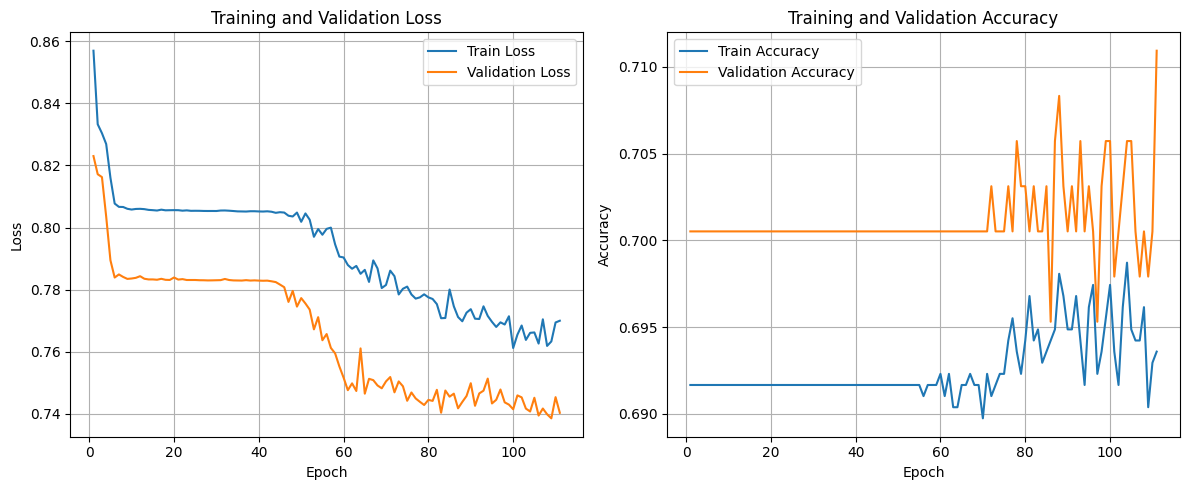

In [70]:
plot_training_history(training_history)

# Пример загрузки и инференса модели

In [72]:
nx_graph, roles = pairs[0]

In [73]:
model = torch.load("civilian_gnn.pth", weights_only=False)

In [74]:
predictions = predict_game_roles(model, nx_graph)
predictions

{'Hayden': {'Villager': 0.978, 'Doctor': 0.0, 'Mafia': 0.021},
 'Kai': {'Villager': 0.794, 'Doctor': 0.0, 'Mafia': 0.206},
 'Zion': {'Villager': 0.749, 'Doctor': 0.0, 'Mafia': 0.25},
 'Marley': {'Villager': 0.869, 'Doctor': 0.0, 'Mafia': 0.131},
 'Jordan': {'Villager': 0.794, 'Doctor': 0.0, 'Mafia': 0.206},
 'Nico': {'Villager': 0.794, 'Doctor': 0.0, 'Mafia': 0.206},
 'Dana': {'Villager': 0.759, 'Doctor': 0.0, 'Mafia': 0.241}}